               CLARANS - FROM SCRATCH

[1/5] CHARGEMENT DES DONNÉES
------------------------------------------------------------
✓ Fichier chargé avec succès!
  Dimensions: 140165 lignes × 16 colonnes

Aperçu des données:
   latitude  longitude   TEB_log  CEC_CLAY  GYPSUM_log  TEXTURE_SOTER_encoded  \
0  36.74886    6.25409  2.995732      53.0    1.960095                    3.0   
1  35.87978    4.44782  3.806662      48.0    2.208274                    3.0   
2  35.70751    5.53337  3.806662      48.0    2.208274                    3.0   
3  32.27667    3.98647  3.806662      71.0    2.028148                    3.0   
4  32.40079    4.00642  3.806662      71.0    2.028148                    3.0   

   ORG_CARBON_log  LCCCODE_encoded  ELEC_COND_log  COARSE  \
0        2.205193              1.0       1.945910    11.0   
1        2.099734              3.0       2.079442     5.0   
2        2.099734             16.0       2.079442     5.0   
3        2.040571             18.0       2.1972

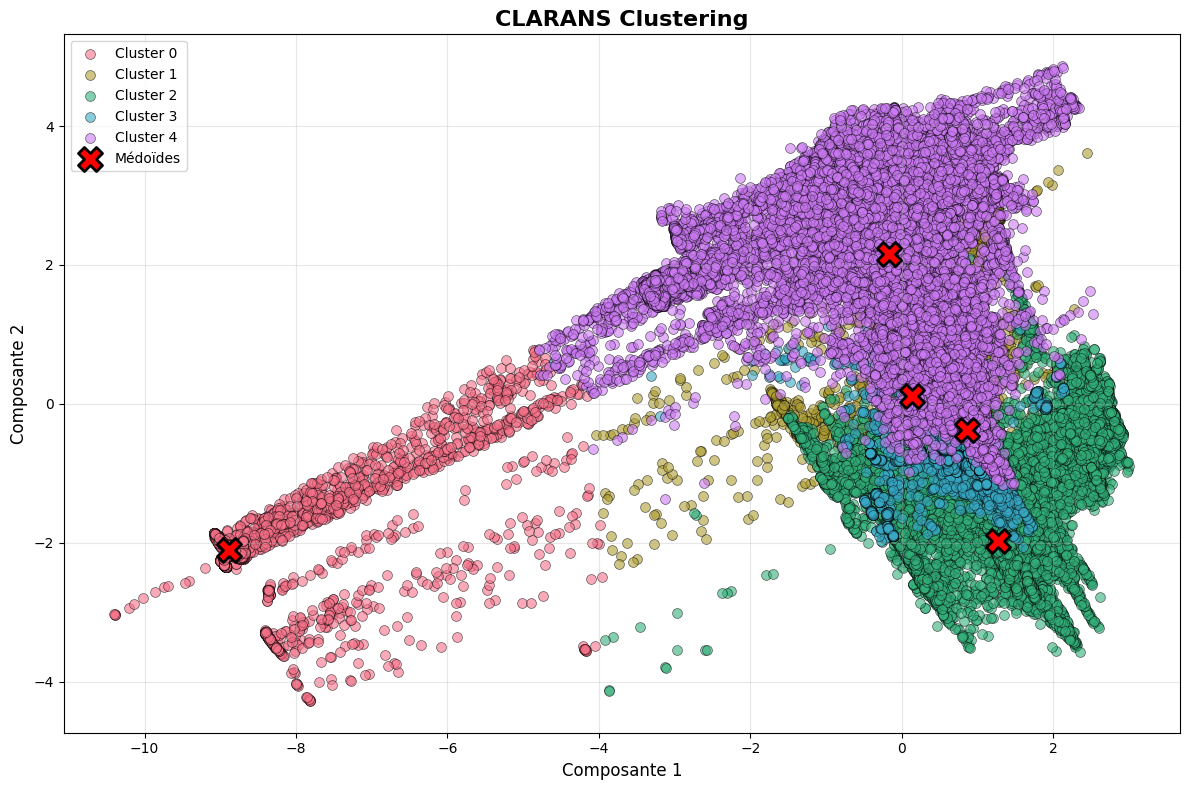


✓ Résultats sauvegardés dans: C:\Users\pc\Desktop\DM\datasets\clarans_results.csv

                    TERMINÉ!


In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

class CLARANS:

    
    def __init__(self, n_clusters=3, numlocal=2, maxneighbor=10, random_state=42):
        self.n_clusters = n_clusters
        self.numlocal = numlocal
        self.maxneighbor = maxneighbor
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None
        self.cost_ = None
        self.n_iterations_ = 0
        
    def _calculate_distance(self, X, centers):
        distances = np.zeros((X.shape[0], len(centers)))
        for i, center_idx in enumerate(centers):
            distances[:, i] = np.sqrt(np.sum((X - X[center_idx])**2, axis=1))
        return distances
    
    def _assign_clusters(self, X, centers):
        distances = self._calculate_distance(X, centers)
        return np.argmin(distances, axis=1)
    
    def _calculate_cost(self, X, centers):
        labels = self._assign_clusters(X, centers)
        cost = 0
        for i, center_idx in enumerate(centers):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                cost += np.sum((cluster_points - X[center_idx])**2)
        return cost
    
    def _get_random_neighbor(self, current_medoids, n_samples):
        np.random.seed(self.random_state + self.n_iterations_)
        new_medoids = current_medoids.copy()
        
        medoid_to_replace = np.random.randint(0, self.n_clusters)
        
        available_points = list(set(range(n_samples)) - set(current_medoids))
        if available_points:
            new_point = np.random.choice(available_points)
            new_medoids[medoid_to_replace] = new_point
        
        return new_medoids
    
    def fit(self, X):
       
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        n_samples = X.shape[0]
        best_medoids = None
        best_cost = float('inf')
        
        print(f"Démarrage de CLARANS avec {self.n_clusters} clusters...")
        print(f"Paramètres: numlocal={self.numlocal}, maxneighbor={self.maxneighbor}")
        
        start_time = time.time()
        
        # Recherche de numlocal minima locaux
        for local_iter in range(self.numlocal):
            print(f"\n--- Recherche du minimum local {local_iter + 1}/{self.numlocal} ---")
            
            # Initialisation aléatoire des médoïdes
            np.random.seed(self.random_state + local_iter)
            current_medoids = np.random.choice(n_samples, self.n_clusters, replace=False)
            current_cost = self._calculate_cost(X, current_medoids)
            
            neighbor_count = 0
            
            # Recherche locale
            while neighbor_count < self.maxneighbor:
                self.n_iterations_ += 1
                
                # Générer un voisin
                neighbor_medoids = self._get_random_neighbor(current_medoids, n_samples)
                neighbor_cost = self._calculate_cost(X, neighbor_medoids)
                
                # Si le voisin est meilleur, l'adopter et réinitialiser le compteur
                if neighbor_cost < current_cost:
                    current_medoids = neighbor_medoids
                    current_cost = neighbor_cost
                    neighbor_count = 0
                    print(f"  Amélioration trouvée! Nouveau coût: {current_cost:.4f}")
                else:
                    neighbor_count += 1
            
            print(f"  Minimum local trouvé avec coût: {current_cost:.4f}")
            
            # Garder le meilleur minimum local
            if current_cost < best_cost:
                best_cost = current_cost
                best_medoids = current_medoids
                print(f"  *** Nouveau meilleur minimum global! ***")
        
        execution_time = time.time() - start_time
        
        # Stocker les résultats
        self.cluster_centers_ = best_medoids
        self.labels_ = self._assign_clusters(X, best_medoids)
        self.cost_ = best_cost
        
        print(f"\n{'='*60}")
        print(f"CLARANS terminé en {execution_time:.2f} secondes")
        print(f"Nombre total d'itérations: {self.n_iterations_}")
        print(f"Coût final: {self.cost_:.4f}")
        print(f"{'='*60}")
        
        return self
    
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return self._assign_clusters(X, self.cluster_centers_)


def evaluate_clustering(X, labels, algorithm_name="CLARANS"):
   
    print(f"\n{'='*60}")
    print(f"ÉVALUATION DU CLUSTERING - {algorithm_name}")
    print(f"{'='*60}")
    
    # Silhouette Score ([-1, 1], plus élevé = meilleur)
    silhouette = silhouette_score(X, labels)
    print(f"\n1. Silhouette Score: {silhouette:.4f}")
    print(f"   Interprétation: {silhouette:.4f}")
    print(f"   - [-1 à 0]: Clustering pauvre")
    print(f"   - [0 à 0.5]: Clustering faible à moyen")
    print(f"   - [0.5 à 0.7]: Clustering raisonnable")
    print(f"   - [0.7 à 1]: Clustering fort")
    
    # Davies-Bouldin Index (plus bas = meilleur)
    davies_bouldin = davies_bouldin_score(X, labels)
    print(f"\n2. Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"   Interprétation: Plus proche de 0 = meilleur")
    print(f"   (Mesure la séparation entre clusters)")
    
    # Calinski-Harabasz Index (plus élevé = meilleur)
    calinski = calinski_harabasz_score(X, labels)
    print(f"\n3. Calinski-Harabasz Index: {calinski:.4f}")
    print(f"   Interprétation: Plus élevé = meilleur")
    print(f"   (Rapport variance inter/intra-cluster)")
    
    # Distribution des clusters
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n4. Distribution des clusters:")
    for cluster_id, count in zip(unique, counts):
        percentage = (count / len(labels)) * 100
        print(f"   Cluster {cluster_id}: {count} points ({percentage:.2f}%)")
    
    print(f"\n{'='*60}")
    
    return {
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski
    }


def visualize_clusters(X, labels, cluster_centers, data_df, title="CLARANS Clustering"):
    
    # Si les données ont plus de 2 dimensions, utiliser PCA pour la visualisation
    if X.shape[1] > 2:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X)
        centers_2d = X_2d[cluster_centers]
        print(f"\nRéduction de dimension avec PCA pour visualisation")
        print(f"Variance expliquée: {sum(pca.explained_variance_ratio_)*100:.2f}%")
    else:
        X_2d = X
        centers_2d = X[cluster_centers]
    
    # Créer la figure
    plt.figure(figsize=(12, 8))
    
    # Palette de couleurs
    colors = sns.color_palette("husl", len(np.unique(labels)))
    
    # Tracer les points
    for i in np.unique(labels):
        mask = labels == i
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                   c=[colors[i]], label=f'Cluster {i}',
                   alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    
    # Tracer les centres (médoïdes)
    plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
               c='red', marker='X', s=300, edgecolors='black',
               linewidth=2, label='Médoïdes', zorder=5)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Composante 1' if X.shape[1] > 2 else 'Feature 1', fontsize=12)
    plt.ylabel('Composante 2' if X.shape[1] > 2 else 'Feature 2', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# =====================================================================
# PROGRAMME PRINCIPAL
# =====================================================================

if __name__ == "__main__":
    
    print("="*70)
    print(" "*15 + "CLARANS - FROM SCRATCH")
    print("="*70)
    
    # 1. CHARGEMENT DES DONNÉES
    print("\n[1/5] CHARGEMENT DES DONNÉES")
    print("-" * 60)
    
    file_path = r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv"
    
    try:
        df = pd.read_csv(file_path)
        print(f"✓ Fichier chargé avec succès!")
        print(f"  Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
        print(f"\nAperçu des données:")
        print(df.head())
        print(f"\nTypes de données:")
        print(df.dtypes)
        print(f"\nValeurs manquantes:")
        print(df.isnull().sum())
        
    except FileNotFoundError:
        print(f"✗ Erreur: Fichier non trouvé à {file_path}")
        print("  Veuillez vérifier le chemin du fichier.")
        exit(1)
    
    # 2. PRÉPARATION DES DONNÉES
    print("\n[2/5] PRÉPARATION DES DONNÉES")
    print("-" * 60)
    
    # Sélectionner uniquement les colonnes numériques
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"Colonnes numériques détectées: {len(numeric_cols)}")
    
    # Supprimer les colonnes d'identifiants si elles existent
    id_cols = [col for col in numeric_cols if 'id' in col.lower() or 'index' in col.lower()]
    if id_cols:
        numeric_cols = [col for col in numeric_cols if col not in id_cols]
        print(f"Colonnes d'ID supprimées: {id_cols}")
    
    X = df[numeric_cols].values
    
    # Gérer les valeurs manquantes
    if np.isnan(X).any():
        print("⚠ Valeurs manquantes détectées, remplissage avec la moyenne...")
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='mean')
        X = imputer.fit_transform(X)
    
    print("Normalisation des données avec StandardScaler...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"✓ Données préparées: {X_scaled.shape[0]} échantillons, {X_scaled.shape[1]} features")
    
    # 3. OPTIMISATION DES PARAMÈTRES (adapté à la taille du dataset)
    print("\n[3/5] CONFIGURATION DES PARAMÈTRES")
    print("-" * 60)
    
    n_samples = X_scaled.shape[0]
    
    # Paramètres adaptés à la taille du dataset
    if n_samples < 1000:
        n_clusters = 3
        numlocal = 3
        maxneighbor = 15
    elif n_samples < 10000:
        n_clusters = 4
        numlocal = 2
        maxneighbor = 10
    else:
        n_clusters = 5
        numlocal = 2
        maxneighbor = 8
    
    print(f"Paramètres optimisés pour {n_samples} échantillons:")
    print(f"  - Nombre de clusters: {n_clusters}")
    print(f"  - Nombre de minima locaux (numlocal): {numlocal}")
    print(f"  - Voisins maximum (maxneighbor): {maxneighbor}")
    
    print("\n[4/5] EXÉCUTION DE CLARANS")
    print("-" * 60)
    
    clarans = CLARANS(
        n_clusters=n_clusters,
        numlocal=numlocal,
        maxneighbor=maxneighbor,
        random_state=42
    )
    
    clarans.fit(X_scaled)
    
    # 5. ÉVALUATION
    print("\n[5/5] ÉVALUATION DES RÉSULTATS")
    print("-" * 60)
    
    metrics = evaluate_clustering(X_scaled, clarans.labels_, "CLARANS")
    
    # Visualisation
    print("\nGénération de la visualisation...")
    visualize_clusters(X_scaled, clarans.labels_, clarans.cluster_centers_, df)
    
    # Sauvegarde des résultats
    df['Cluster'] = clarans.labels_
    output_path = r"C:\Users\pc\Desktop\DM\datasets\clarans_results.csv"
    df.to_csv(output_path, index=False)
    print(f"\n✓ Résultats sauvegardés dans: {output_path}")
    
    print("\n" + "="*70)
    print(" "*20 + "TERMINÉ!")
    print("="*70)

                         🔬 CLARANS (sklearn prédéfini)

[1/5] 📂 CHARGEMENT DES DONNÉES
--------------------------------------------------------------------------------
✓ Fichier chargé: 140165 lignes × 16 colonnes

[2/5] ⚙️ PRÉPARATION DES DONNÉES
--------------------------------------------------------------------------------
✓ Données normalisées: 140165 échantillons, 16 features

[3/5] 🎛️ CONFIGURATION DES PARAMÈTRES
--------------------------------------------------------------------------------
Paramètres pour 140165 échantillons:
  • Clusters: 5
  • Numlocal: 2
  • Maxneighbor: 8
  • Algorithme: CLARANS (sklearn)

[4/5] 📚 EXÉCUTION CLARANS
--------------------------------------------------------------------------------
🔧 CLARANS - Démarrage avec 5 clusters
   🔧 CLARANS: numlocal=2, maxneighbor=8
   🔍 Recherche locale 1/2... Coût: 434730.64
   🔍 Recherche locale 2/2... Coût: 400844.46
   ✓ Terminé en 4.15s

[5/5] 📊 RÉSULTATS ET VISUALISATION
---------------------------------------

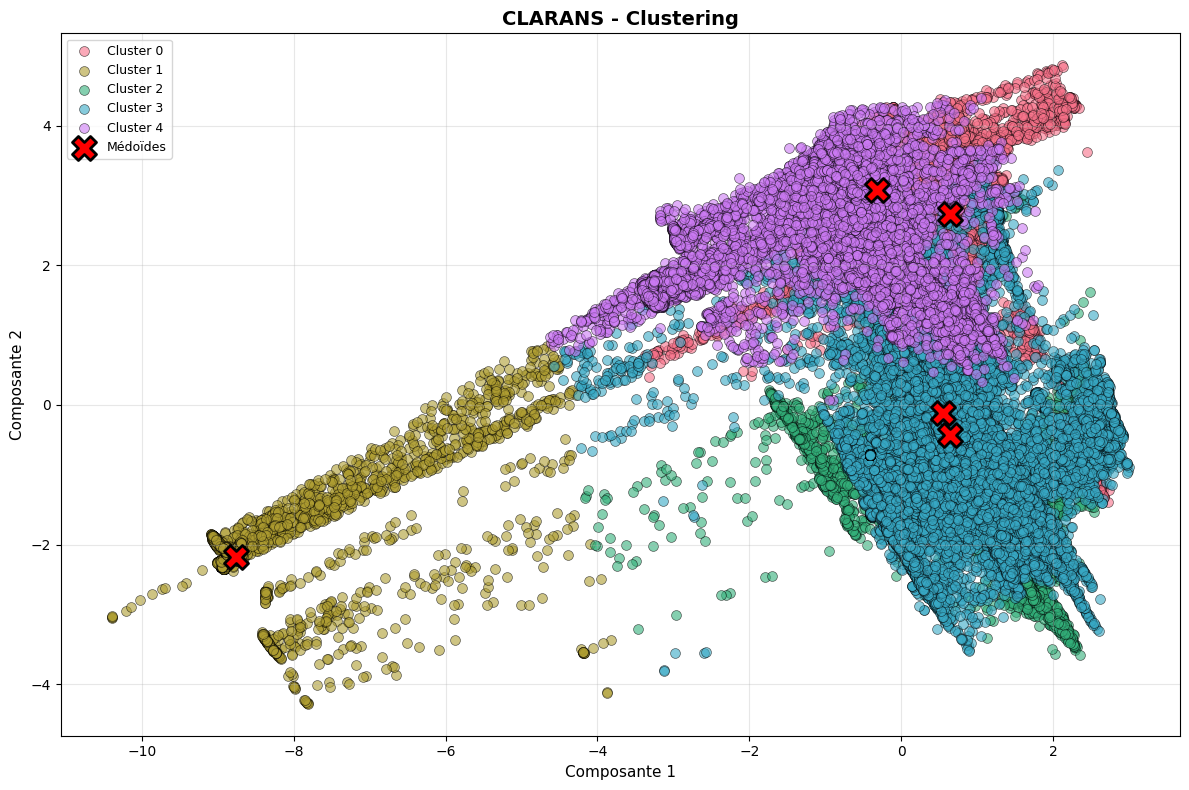


💾 Résultats sauvegardés: C:\Users\pc\Desktop\DM\datasets\clarans_results.csv

                              ✅ TERMINÉ!


In [11]:
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import check_random_state
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# CLARANS avec sklearn 
# =====================================================================

class CLARANS:
   
    
    def __init__(self, n_clusters=3, numlocal=2, maxneighbor=None, random_state=42):
        
        self.n_clusters = n_clusters
        self.numlocal = numlocal
        self.maxneighbor = maxneighbor
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None
        self.medoid_indices_ = None
        self.inertia_ = None
        
    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        n_samples = X.shape[0]
        rng = check_random_state(self.random_state)
        
        if self.maxneighbor is None:
            if n_samples < 1000:
                self.maxneighbor = 15
            elif n_samples < 10000:
                self.maxneighbor = 10
            else:
                self.maxneighbor = 8
        
        print(f"   🔧 CLARANS: numlocal={self.numlocal}, maxneighbor={self.maxneighbor}")
        
        best_medoid_indices = None
        best_cost = float('inf')
        
        # Recherche de numlocal minima locaux
        for local_iteration in range(self.numlocal):
            print(f"   🔍 Recherche locale {local_iteration + 1}/{self.numlocal}...", end=" ")
            
            # Initialisation aléatoire des médoïdes 
            current_medoids = rng.choice(n_samples, self.n_clusters, replace=False)
            
            # Assigner les labels
            distances = euclidean_distances(X, X[current_medoids])
            labels = np.argmin(distances, axis=1)
            
            # Calculer le coût initial 
            current_cost = self._calculate_cost_sklearn(X, current_medoids, labels)
            
            # Recherche locale randomisée
            neighbor_count = 0
            while neighbor_count < self.maxneighbor:
                # Choisir aléatoirement un médoïde à remplacer
                medoid_to_replace = rng.randint(0, self.n_clusters)
                
                # Choisir aléatoirement un point non-médoïde
                non_medoid = rng.randint(0, n_samples)
                while non_medoid in current_medoids:
                    non_medoid = rng.randint(0, n_samples)
                
                # Créer nouveau voisin
                new_medoids = current_medoids.copy()
                new_medoids[medoid_to_replace] = non_medoid
                
                # Évaluer le voisin 
                new_distances = euclidean_distances(X, X[new_medoids])
                new_labels = np.argmin(new_distances, axis=1)
                new_cost = self._calculate_cost_sklearn(X, new_medoids, new_labels)
                
                # Si meilleur, accepter et redémarrer la recherche locale
                if new_cost < current_cost:
                    current_medoids = new_medoids
                    labels = new_labels
                    current_cost = new_cost
                    neighbor_count = 0  
                else:
                    neighbor_count += 1
            
            print(f"Coût: {current_cost:.2f}")
            
            # Garder le meilleur minimum local
            if current_cost < best_cost:
                best_cost = current_cost
                best_medoid_indices = current_medoids
        
        # Finaliser avec les meilleurs médoïdes 
        final_distances = euclidean_distances(X, X[best_medoid_indices])
        self.labels_ = np.argmin(final_distances, axis=1)
        self.medoid_indices_ = best_medoid_indices
        self.cluster_centers_ = X[best_medoid_indices]
        self.inertia_ = best_cost
        
        return self
    
    def _calculate_cost_sklearn(self, X, medoid_indices, labels):
        cost = 0
        for i in range(self.n_clusters):
            cluster_mask = labels == i
            if np.any(cluster_mask):
                cluster_points = X[cluster_mask]
                medoid = X[medoid_indices[i]].reshape(1, -1)
                cost += np.sum(euclidean_distances(cluster_points, medoid))
        return cost
    
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        distances = euclidean_distances(X, self.cluster_centers_)
        return np.argmin(distances, axis=1)


# =====================================================================
# FONCTIONS D'ÉVALUATION ET VISUALISATION 
# =====================================================================

def evaluate_clustering(X, labels, algorithm_name, execution_time):
    
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    
    unique, counts = np.unique(labels, return_counts=True)
    distribution = {f"Cluster_{i}": count for i, count in zip(unique, counts)}
    
    return {
        'algorithm': algorithm_name,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski,
        'execution_time': execution_time,
        'distribution': distribution
    }


def print_results(results):
    
    print("\n" + "="*80)
    print(" "*30 + "📊 RÉSULTATS")
    print("="*80)
    
    print(f"\n{'Métrique':<30} {'Valeur':<20}")
    print("-"*50)
    
    print(f"{'Silhouette Score':<30} {results['silhouette']:<20.4f}")
    print(f"{'Davies-Bouldin Index':<30} {results['davies_bouldin']:<20.4f}")
    print(f"{'Calinski-Harabasz Index':<30} {results['calinski_harabasz']:<20.4f}")
    print(f"{'Temps d\'exécution (s)':<30} {results['execution_time']:<20.2f}")
    
    print("-"*50)
    
    # Interprétation
    print("\n📖 INTERPRÉTATION DES MÉTRIQUES:")
    print("-"*50)
    print(f"1. Silhouette Score [-1, 1]: {results['silhouette']:.4f}")
    if results['silhouette'] > 0.7:
        print(f"   ✓ Clustering FORT (> 0.7)")
    elif results['silhouette'] > 0.5:
        print(f"   ✓ Clustering RAISONNABLE (0.5-0.7)")
    elif results['silhouette'] > 0.25:
        print(f"   ⚠ Clustering MOYEN (0.25-0.5)")
    else:
        print(f"   ✗ Clustering FAIBLE (< 0.25)")
    
    print(f"\n2. Davies-Bouldin Index [0, ∞]: {results['davies_bouldin']:.4f}")
    print(f"   Plus bas = meilleur | Mesure la séparation entre clusters")
    
    print(f"\n3. Calinski-Harabasz Index [0, ∞]: {results['calinski_harabasz']:.4f}")
    print(f"   Plus élevé = meilleur | Ratio variance inter/intra-cluster")
    
    print("\n" + "="*80)
    
    # Distribution
    print("\n📈 DISTRIBUTION DES CLUSTERS:")
    print("-"*50)
    print(f"{'Cluster':<15} {'Nombre de points':<20} {'Pourcentage':<15}")
    print("-"*50)
    
    total = sum(results['distribution'].values())
    for cluster in sorted(results['distribution'].keys()):
        count = results['distribution'][cluster]
        pct = count / total * 100
        print(f"{cluster:<15} {count:<20} {pct:.2f}%")
    
    print("="*80)


def visualize_clustering(X, labels, medoids):
    
    if X.shape[1] > 2:
        pca = PCA(n_components=2, random_state=42)
        X_2d = pca.fit_transform(X)
        medoids_2d = X_2d[medoids]
        variance_explained = sum(pca.explained_variance_ratio_) * 100
        print(f"\n📉 Réduction PCA | Variance expliquée: {variance_explained:.2f}%")
    else:
        X_2d = X
        medoids_2d = X[medoids]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = sns.color_palette("husl", len(np.unique(labels)))
    for i in np.unique(labels):
        mask = labels == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[colors[i]], 
                   label=f'Cluster {i}', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    
    ax.scatter(medoids_2d[:, 0], medoids_2d[:, 1],
               c='red', marker='X', s=300, edgecolors='black', linewidth=2, 
               label='Médoïdes', zorder=5)
    
    ax.set_title('CLARANS - Clustering', fontsize=14, fontweight='bold')
    ax.set_xlabel('Composante 1', fontsize=11)
    ax.set_ylabel('Composante 2', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# =====================================================================
# PROGRAMME PRINCIPAL
# =====================================================================

if __name__ == "__main__":
    
    print("="*80)
    print(" "*25 + "🔬 CLARANS (sklearn prédéfini)")
    print("="*80)
    
    # 1. CHARGEMENT
    print("\n[1/5] 📂 CHARGEMENT DES DONNÉES")
    print("-" * 80)
    
    file_path = r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv"
    
    try:
        df = pd.read_csv(file_path)
        print(f"✓ Fichier chargé: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    except FileNotFoundError:
        print(f"✗ Erreur: Fichier non trouvé à {file_path}")
        exit(1)
    
    # 2. PRÉPARATION 
    print("\n[2/5] ⚙️ PRÉPARATION DES DONNÉES")
    print("-" * 80)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    id_cols = [col for col in numeric_cols if 'id' in col.lower() or 'index' in col.lower()]
    if id_cols:
        numeric_cols = [col for col in numeric_cols if col not in id_cols]
        print(f"Colonnes d'ID supprimées: {id_cols}")
    
    X = df[numeric_cols].values
    
    if np.isnan(X).any():
        print("⚠ Remplissage avec SimpleImputer (sklearn)...")
        imputer = SimpleImputer(strategy='mean')
        X = imputer.fit_transform(X)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"✓ Données normalisées: {X_scaled.shape[0]} échantillons, {X_scaled.shape[1]} features")
    
    # 3. CONFIGURATION
    print("\n[3/5] 🎛️ CONFIGURATION DES PARAMÈTRES")
    print("-" * 80)
    
    n_samples = X_scaled.shape[0]
    
    # Paramètres adaptés à la taille du dataset
    if n_samples < 1000:
        n_clusters = 3
        numlocal = 3
        maxneighbor = 15
    elif n_samples < 10000:
        n_clusters = 4
        numlocal = 2
        maxneighbor = 10
    else:
        n_clusters = 5
        numlocal = 2
        maxneighbor = 8
    
    print(f"Paramètres pour {n_samples} échantillons:")
    print(f"  • Clusters: {n_clusters}")
    print(f"  • Numlocal: {numlocal}")
    print(f"  • Maxneighbor: {maxneighbor}")
    print(f"  • Algorithme: CLARANS (sklearn)")
    
    # 4. EXÉCUTION CLARANS
    print("\n[4/5] 📚 EXÉCUTION CLARANS")
    print("-" * 80)
    print(f"🔧 CLARANS - Démarrage avec {n_clusters} clusters")
    
    start_time = time.time()
    clarans = CLARANS(
        n_clusters=n_clusters,
        numlocal=numlocal,
        maxneighbor=maxneighbor,
        random_state=42
    )
    clarans.fit(X_scaled)
    execution_time = time.time() - start_time
    
    print(f"   ✓ Terminé en {execution_time:.2f}s")
    
    results = evaluate_clustering(
        X_scaled,
        clarans.labels_,
        "CLARANS",
        execution_time
    )
    
    # 5. RÉSULTATS
    print("\n[5/5] 📊 RÉSULTATS ET VISUALISATION")
    print("-" * 80)
    
    print_results(results)
    
    print("\n🎨 Génération de la visualisation...")
    visualize_clustering(
        X_scaled,
        clarans.labels_,
        clarans.medoid_indices_
    )
    
    # Sauvegarde
    df['Cluster_CLARANS'] = clarans.labels_
    output_path = r"C:\Users\pc\Desktop\DM\datasets\clarans_results.csv"
    df.to_csv(output_path, index=False)
    print(f"\n💾 Résultats sauvegardés: {output_path}")
    
    print("\n" + "="*80)
    print(" "*30 + "✅ TERMINÉ!")
    print("="*80)